## Setup

In [1]:
import matplotlib.pyplot as plt

Below are the standard imports that we use for all hybridlane circuits.

In [2]:
import numpy as np
import pennylane as qml
import hybridlane as hqml

As hybridlane leverages the graph decomposition system of PennyLane, we'll go ahead and enable that now.

In [3]:
qml.decomposition.enable_graph()

## Demo 1: Quantum phase estimation

This demo aims to show some functionality of Hybridlane:
- Introduce custom operators and hybridlane circuits
- Using existing Pennylane qubit algorithms
- Exporting circuits to OpenQASM 3

For a nice review of quantum phase estimation (QPE), see the [PennyLane blog post](https://pennylane.ai/qml/demos/tutorial_qpe). Additionally, this example was inspired from the Bosonic Qiskit tutorial on [simulating the dispersive hamiltonian](https://github.com/C2QA/bosonic-qiskit/blob/c02e0f16f33bfd6f1784725cf50158d1a21c192a/tutorials/jaynes-cummings-model/jaynes-cummings-dispersive.ipynb).

---


Consider the dispersive Hamiltonian representing our system of interest

$$H = \omega_r \hat{n} - \frac{\omega_q}{2} Z - \frac{\chi}{2} Z\hat{n}$$

> ⚠️ Here we use the minus sign in front of $Z$ operators because in Hybridlane, $\ket{0} = \ket{g}$ is the +1 eigenstate of $Z$ to match the typical quantum information convention. This means that $-\frac{1}{2}Z$ is the energy operator of a spin state instead of $\frac{1}{2}Z$.

Imagine that we would like to measure the energy of an unknown eigenstate $\ket{\psi}$. We can do this by applying QPE to the unitary $U(t) = e^{-iHt}$, provided we have the ability to synthesize the qubit-controlled variant $cU(t) := \ket{0}\bra{0}I + \ket{1}\bra{1}U(t)$. This would result in measuring the phase $\phi$ such that

$$e^{-iEt} = e^{2\pi i \phi}$$

which can then be related back to the energy as $E = \frac{-2\pi\phi}{t}$. We'll assume $t=1$ for simplicity in the code.

### Defining the unitary $U(t)$

First, we need to define our gate $U(t) = e^{-iHt}$. This follows the usual PennyLane syntax.

In [4]:
from pennylane.ops import Operation

class U(Operation):
    num_params = 4
    num_wires = 2

    resource_keys = set()

    def __init__(self, t, omega_r = 1, omega_q = -1, chi = 0.1, wires=None, id=None):
        super().__init__(t, omega_r, omega_q, chi, wires=wires, id=id)

    def label(self, decimals: int | None = None, base_label: str | None = None, cache: dict | None = None) -> str:
        return super().label(decimals, base_label or "U", cache)

    @property
    def resource_params(self):
        return {}

This means we have abstractly defined our gate $U(t)$, but we need to express this in terms of more primitive gates (or our simulator won't understand it). The terms of $H$ commute (as conveniently chosen), so we can easily write the decomposition as

$$
\begin{align*}
U(t) &= e^{-i\omega_r t \hat{n}}e^{i\frac{\omega_q t}{2} Z}e^{i \frac{\chi t}{2} Z\hat{n}} \\
     &= R(\omega_r t)R_z(-\omega_q t)CR(-\chi t).
\end{align*}
$$

Using the gates defined in PennyLane and hybridlane,
- $R(\omega_r t)$: `hqml.R(qumode)`, the phase-space rotation gate
- $R_z(-\omega_q t)$: `qml.RZ(qubit)`, the qubit rotation about the $Z$ axis
- $CR(-\chi t)$: `hqml.CR(qubit, qumode)`, the qubit-_conditioned_ phase-space rotation gate

Decompositions are registered using `qml.add_decomps` and a function mapping the gate parameters into a series of other gate invocations. Below we define our gate and register it with the graph decomposition system.

In [5]:
# The decomposition in terms of R, Rz, and CR
@qml.register_resources({hqml.R: 1, hqml.CR: 1, qml.RZ: 1})
def _decomp(t, omega_r, omega_q, chi, wires):
    qubit, qumode = wires
    hqml.R(t*omega_r, qumode)
    qml.RZ(-t*omega_q, qubit)
    hqml.CR(-t*chi, wires)

qml.add_decomps(U, _decomp)

We can go ahead and define a simple circuit that performs time evolution under $U(t)$. We displace the initial qumode state to $\sqrt{2}$ in standard units (or 1 in Wigner units) and measure $\langle \hat{x}(t) \rangle$.

 > **Note**: The `@qml.batch_input(2)` statement is just for convenience -- since `t` is a "trainable parameter" with index 2 in the circuit's total parameters, using this annotation lets us pass a numpy array for time values instead of one-by-one.

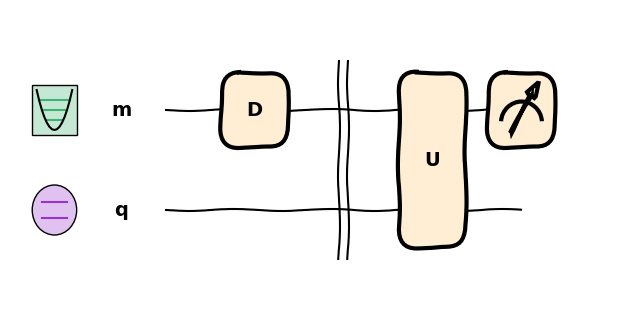

In [6]:
dev = qml.device("bosonicqiskit.hybrid", max_fock_level=16, hbar=1)

@qml.batch_input(2)
@qml.qnode(dev)
def time_evolution(t):
    hqml.D(1.0, 0, "m")
    qml.Barrier()
    U(t, wires=["q", "m"])
    return hqml.expval(hqml.X("m"))

hqml.draw_mpl(time_evolution, level="user", style="sketch")([1])
plt.show()

Simulating the evolution for different values of $t$, we obtain oscillation of the qumode's position.

> 💡 **Tip**: Try changing the state of the qubit by adding an $X$ gate prior to the evolution.

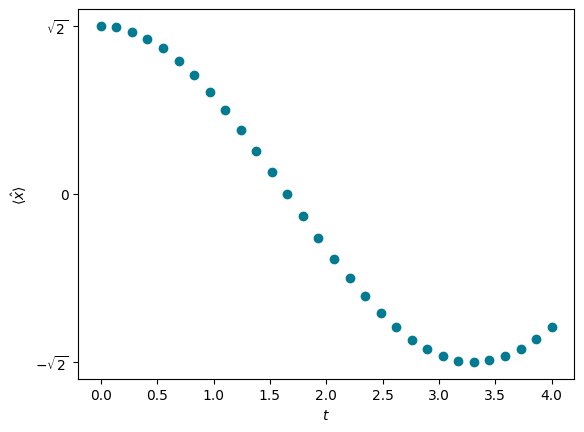

In [7]:
t = np.linspace(0, 4, 30)
expvals = time_evolution(t)
plt.scatter(t, expvals, color="xkcd:ocean")
plt.yticks([-np.sqrt(2), 0, np.sqrt(2)], [r"$-\sqrt{2}$", "0", r"$\sqrt{2}$"])
plt.xlabel("$t$")
plt.ylabel(r"$\langle \hat{x} \rangle$")
plt.show()

Two other properties might be useful for our unitary gate. Below we encode that $U^\dagger(t) = U(-t)$ and $U^z(t) = U(zt)$.

In [8]:
# The decomposition U†(t) = U(-t)
@qml.register_resources({U: 1})
def _u_adjoint(t, *params, wires, **_):
    U(-t, *params, wires=wires)

# The decomposition U^z(t) = U(zt)
@qml.register_resources({U: 1})
def _u_pow(t, *params, wires, z, **_):
    U(z * t, *params, wires=wires)

qml.add_decomps("Adjoint(U)", _u_adjoint)
qml.add_decomps("Pow(U)", _u_pow)

Using with these decompositions, we can now implement the actual QPE circuit for our Hamiltonian. We'll use the high-level [QuantumPhaseEstimation](https://docs.pennylane.ai/en/stable/code/api/pennylane.QuantumPhaseEstimation.html) template provided by Pennylane to reduce work and show that Hybridlane integrates with your favorite algorithms.

In [9]:
from pennylane.templates import QuantumPhaseEstimation
from pennylane.wires import Wires
from hybridlane.devices.bosonic_qiskit.gates import supported_operations as native_gates
from hybridlane.sa import ComputationalBasis, BasisSchema

dev = qml.device('bosonicqiskit.hybrid', max_fock_level=8)

# Define the Hamiltonian parameters
t = 1
omega_r = 2
omega_q = 5
chi = 0.1

# Construct the unitary U(t) outside of the circuit so it's not queued into the circuit operations
target_wires = ("q", "m")
time_evo_gate = U(t, omega_r=omega_r, omega_q=omega_q, chi=chi, wires=target_wires)


@qml.transforms.decompose(gate_set=native_gates)
@qml.set_shots(15)
@qml.qnode(dev)
def circuit_qpe(n_bits):
    # State prep: We'll prepare the eigenstate |g, 4> = |0, 4>.
    hqml.FockState(4, ["q", "m"])

    # Use Pennylane QPE template
    estimation_wires = range(n_bits)
    QuantumPhaseEstimation(time_evo_gate, estimation_wires=estimation_wires)

    # Define the computational basis measurement over the estimation qubits.
    # In general, Discrete can mean Z basis (qubits) or Fock basis (qumodes), but hybridlane understands it's
    # Z-basis because estimation_wires are all qubits.
    schema = BasisSchema(
        {Wires(w): ComputationalBasis.Discrete for w in estimation_wires}
    )
    return hqml.sample(schema=schema)

The high-level circuit we defined is quite short:

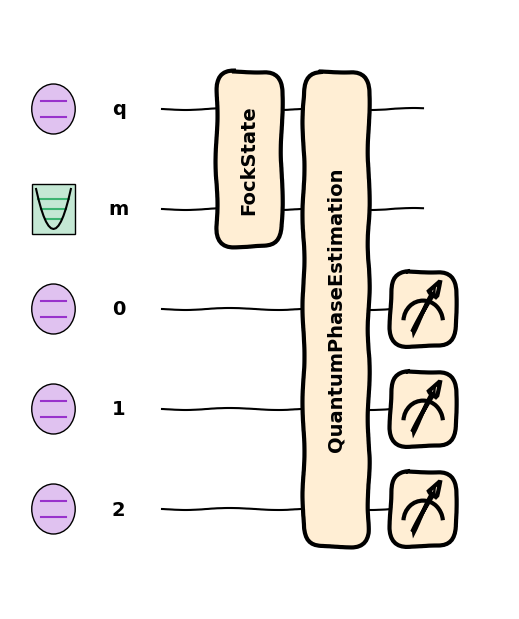

In [10]:
hqml.draw_mpl(circuit_qpe, level="top", style="sketch")(3)
plt.show()

Changing the decomposition to the `device` level shows the full circuit that will get executed on the simulator. Notice how it uses the rules we gave it. The overall circuit depth is only one $cU$ gate per estimation qubit because $U(t)$ is an arbitrary-angle gate. This would be much deeper if our unitary was made of discrete gates (e.g. $Z$, $T$), or if we hadn't taught PennyLane how to take powers of our gate $U$ because then it would repeat $U$ to synthesize powers.

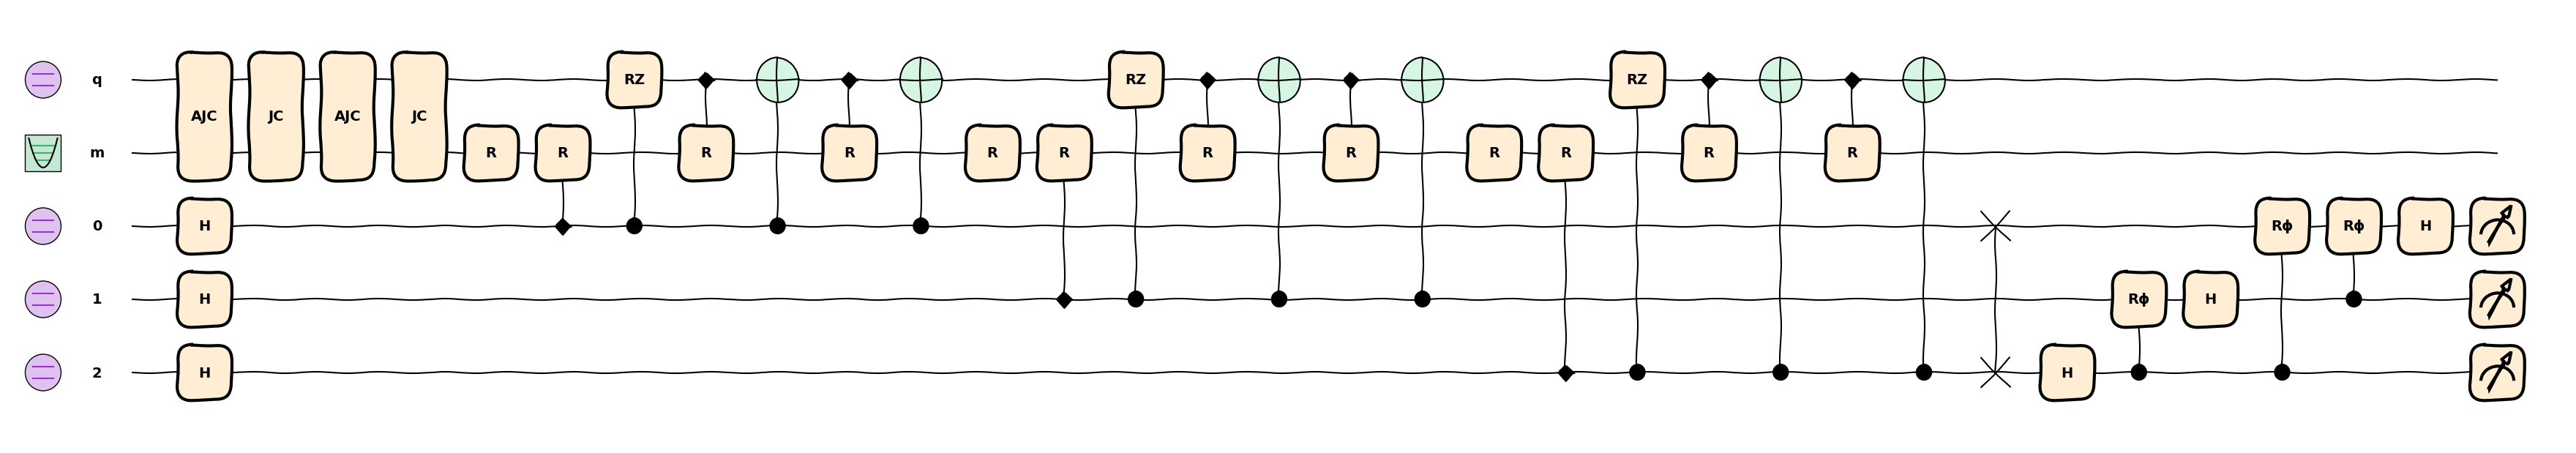

In [11]:
hqml.draw_mpl(circuit_qpe, level="device", style="sketch")(3)
plt.show()

Here we use a small number of shots to show what the output looks like. Different from what you might be used to in PennyLane, hybridlane returns a dictionary that maps the wire labels to the measured basis states. From the QPE template, wire `0` is the MSB.

In [12]:
bitstrings = circuit_qpe(10)
bitstrings.basis_states

{0: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 1: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 2: array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=uint8),
 3: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 4: array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1], dtype=uint8),
 5: array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 6: array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 7: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 8: array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 9: array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0], dtype=uint8)}

To generate a histogram, one can use a larger number of shots with the `qml.set_shots` transform. We define a utility function to convert the basis states into the phase angles $\phi$.

> ❗ We use $1 - \phi$ because phase output by our circuit is in the range $(-1, 0]$ from our definition that $U = e^{-iHt}$. If we used a positive $e^{iHt}$, then this wouldn't require conversion.

Mode: ModeResult(mode=np.float64(5.301437602932776), count=np.int64(863))


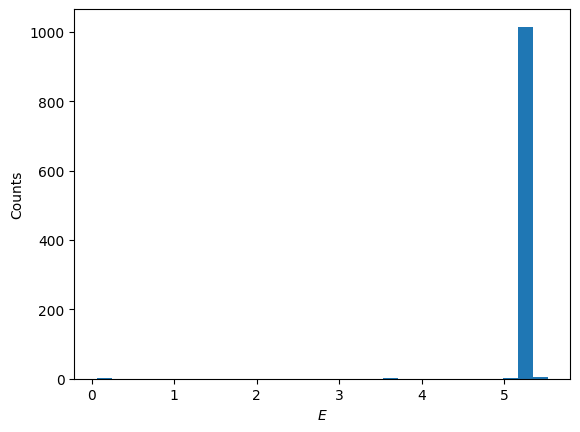

In [13]:
from scipy.stats import mode

def bitstring_to_phase(result):
    arrs = [2 ** (-w - 1) * bits for w, bits in result.basis_states.items()]
    return sum(arrs)

bitstrings = qml.set_shots(circuit_qpe, shots=1024)(10)
phase_estimated = bitstring_to_phase(bitstrings)
energies = 2 * np.pi * (1 - phase_estimated) / t

print(f"Mode: {mode(energies)}")
plt.hist(energies, bins=30)
plt.xlabel("$E$")
plt.ylabel("Counts")
plt.show()

We obtain a large concentration around $E = 5.3$, suggesting we did prepare an eigenstate.

> 📃 **Exercise**: Vary the hamiltonian parameters and state preparation circuit. Do you get the energy you expect? (If not, file an issue on Github! 🐛)

### Exporting to OpenQASM

Hybridlane provides a utility function `to_openqasm` that exports circuits to a variant of OpenQASM 3 with some hybrid CV-DV modifications. Here's what our circuit looks like, using a small number of estimation qubits to keep the output short.

In [14]:
qasm = hqml.to_openqasm(circuit_qpe, precision=5, level="device")(3)
print(qasm)

OPENQASM 3.0;
include "stdgates.inc";
include "cvstdgates.inc";

qubit[4] q;
qumode[1] m;

def state_prep() {
    reset q;
    reset m;
    cv_ajc(1.57080, 1.57080) q[0], m[0];
    cv_jc(1.11072, 1.57080) q[0], m[0];
    cv_ajc(0.90690, 1.57080) q[0], m[0];
    cv_jc(0.78540, 1.57080) q[0], m[0];
    h q[1];
    h q[2];
    h q[3];
    cv_r(4.00000) m[0];
    cv_cr(-8.00000) q[1], m[0];
    crz(-20.00000) q[1], q[0];
    cv_cr(-0.20000) q[0], m[0];
    cx q[1], q[0];
    cv_cr(0.20000) q[0], m[0];
    cx q[1], q[0];
    cv_r(2.00000) m[0];
    cv_cr(-4.00000) q[2], m[0];
    crz(-10.00000) q[2], q[0];
    cv_cr(-0.10000) q[0], m[0];
    cx q[2], q[0];
    cv_cr(0.10000) q[0], m[0];
    cx q[2], q[0];
    cv_r(1.00000) m[0];
    cv_cr(-2.00000) q[3], m[0];
    crz(-5.00000) q[3], q[0];
    cv_cr(-0.05000) q[0], m[0];
    cx q[3], q[0];
    cv_cr(0.05000) q[0], m[0];
    cx q[3], q[0];
    swap q[1], q[3];
    h q[3];
    u1(-0.78540) q[3];
    cx q[3], q[2];
    u1(0.78540) q[2];
    cx

Notice that we have a `qumode` keyword to declare qumode registers and a standard library `cvstdgates.inc` of hybrid gates. You can find the standard library under `examples/cvstdgates.inc`. While not shown in this example, hybridlane will also try to insert homodyne or PNR measurements into the intermediate representation (IR) for measured qumodes.

**Exercise**: Try using the `strict=True` flag in the `to_openqasm` function and note what changes happen to the IR.

## Demo 2: Programming the ion trap

This demo aims to show some features regarding the Sandia Qscout ion trap:
- Introduce the `sandiaqscout.hybrid` device and how to program at the native gate level
- Give a simple calibration example and show a full workflow from simulation to transpiling and exporting to Jaqal

The calibration example is based on Bosonic Qiskit's tutorial on [simulating displacement calibration](https://github.com/C2QA/bosonic-qiskit/blob/c02e0f16f33bfd6f1784725cf50158d1a21c192a/tutorials/displacement-calibration/displacement-calibration.ipynb).

---

In this demo, we'll be programming hybrid circuits for the Sandia QSCOUT ion trap and replicating a common workflow used in qubit software:

defining the circuit → simulating → transpiling to hardware → executing

We won't be able to actually execute the circuit because there's no cloud access to the device, but we'll export the circuit to the [Jaqal](https://arxiv.org/abs/2008.08042) format used by the ion trap. Additionally, we provide this plotting style to draw circuits on the ion trap.

In [15]:
from hybridlane.devices.sandia_qscout import get_default_style

draw_options = get_default_style()

### Hardware-level programming

Hybridlane contains all of the relevant Qscout code under the `hybridlane.devices.sandia_qscout` package, containing
- `QscoutIonTrap`: A dummy backend that serves as a circuit compilation target and validates that gates obey the hardware constraints
- `ops`: An implementation of the native qumode gates. (You can use the standard Pennylane qubit gates too)
- `to_jaqal`: A transformation similar to `to_openqasm` that outputs a circuit to the Jaqal format.

The currently available native qubit-qumode gates are:
- **JaynesCummings** (`JC`): The red sideband gate
- **AntiJaynesCummings** (`AJC`): The blue sideband gate
- **SidebandProbe** (`Rt_SBProbe`): A general sideband operation
- **ConditionalXDisplacement** (`xCD`): A conditional displacement with an $X$ generator instead of a $Z$ generator
- **ConditionalYDisplacement** (`yCD`): A conditional displacement with an $Y$ generator instead of a $Z$ generator
- **ConditionalDisplacement** (`zCD`): The usual conditional displacement. Technically this one is implemented as a macro on the hardware.
- **ConditionalXSqueezing** (`RampUp`): A conditional squeezing similarly based on $X$ instead of $Z$
- **FockState** (`FockStatePrep`): A sometimes-native gate that prepares a Fock state
- **NativeBeamsplitter** (`Beamsplitter`): The beamsplitter operation the device, renamed to avoid conflict with the Hybridlane `Beamsplitter` gate since the parameters differ

Each corresponds to the Jaqal instruction given in the parentheses. You can get the full list of native gates with

In [16]:
from hybridlane.devices.sandia_qscout.device import NATIVE_GATES

NATIVE_GATES

{'Adjoint(S)',
 'Adjoint(SX)',
 'AntiJaynesCummings',
 'ConditionalDisplacement',
 'ConditionalXDisplacement',
 'ConditionalXSqueezing',
 'ConditionalYDisplacement',
 'FockState',
 'GlobalPhase',
 'Identity',
 'IsingXX',
 'IsingYY',
 'IsingZZ',
 'JaynesCummings',
 'NativeBeamsplitter',
 'PauliX',
 'PauliY',
 'PauliZ',
 'R',
 'RX',
 'RY',
 'RZ',
 'S',
 'SX',
 'SidebandProbe'}


Many of these gates have constraints (e.g. only working on the "tilt" modes), so the way to guarantee you define an executable circuit is to use the hardware wires. The qubits can be addressed through integers $i \in 0,\dots,n-1$, while the hardware qumodes use strings with the format `"m<manifold>i<index>"`, where $manifold \in \{0, 1\}$ and $index \in 0, ..., n-1$, giving $2n$ qumodes. However, the center-of-mass (COM) qumodes ($index = 0$) are often undesirable, and so by default, the `sandiaqscout.hybrid` device only lets you use modes $1\dots n-1$. You can use the COM qumodes if you pass the flag `use_com_modes=True` to the device.

Here's a simple example of performing a conditional displacement on a tilt mode ($index = 1$).

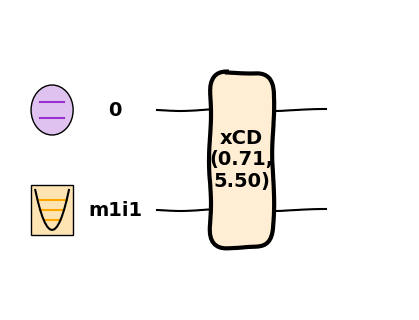

In [17]:
from hybridlane.devices.sandia_qscout import ops

dev = qml.device('sandiaqscout.hybrid', use_virtual_wires=False, n_qubits=6)

@qml.set_shots(10)
@qml.qnode(dev)
def circuit(beta):
    hqml.XCD(qml.math.abs(beta), qml.math.angle(beta), [0, "m1i1"])

hqml.draw_mpl(circuit, style="sketch", decimals=2, level="device", **draw_options)(0.5 - 0.5j)
plt.show()

### Virtual wires

By using the default `use_virtual_wires=True` flag, the device can also perform virtual wire assignment to satisfy the constraints of the device, if possible. We'll also show some of the decompositions built-in to the device.

Consider the following circuit:

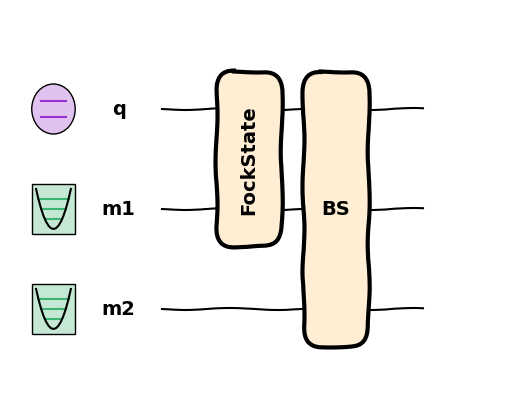

In [18]:
dev = qml.device('sandiaqscout.hybrid', n_qubits=6)

@qml.set_shots(10)
@qml.qnode(dev)
def circuit():
    hqml.FockState(3, ["q", "m1"])
    ops.NativeBeamsplitter(0.1, 0.1, 0.1, 0.1, ["q", "m1", "m2"])

hqml.draw_mpl(circuit, style="sketch", **draw_options)()
plt.show()

The `FockState` instruction can be applied to any qumode. The `Beamsplitter` gate however is constrained (currently) to work only on the tilt modes of each manifold, therefore restricting the domain of assignments of `m1` and `m2`. We can draw the circuit at the `device` level to see the assignments:

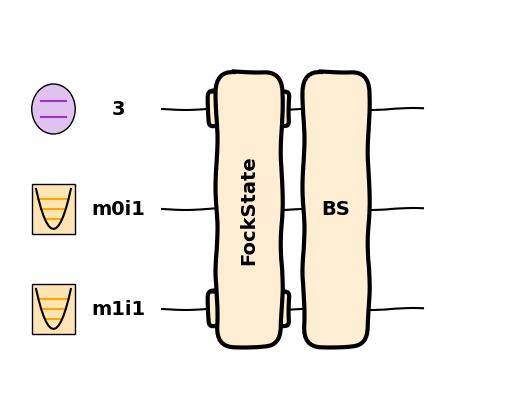

In [19]:
hqml.draw_mpl(circuit, style="sketch", level="device", **draw_options)()
plt.show()

### The full pipeline

Now we'll consider an example circuit composed of gates that can be simulated in Bosonic Qiskit and also decomposed to the native ion trap gates (that is a rather limited set, to be fair).

We'll use this example of calibrating a conditional displacement gate. Note that while the original example uses some displacement gates, we can synthesize them on the ion trap using conditional displacement gates - as long as we start use a clean (reset) ancilla qubit. Therefore, the circuit on the qumode and qubit is effectively

$$
\begin{align*}
U(\beta) &= H~D(-i\beta)~CD(-\beta)~D(i\beta)~CD(\beta)~H \\
     &= R_x(-4\beta^2)
\end{align*}
$$

following the analysis in [arXiv:2407.10381](https://arxiv.org/abs/2407.10381) (see p. 68-69). This results in a final $Z$ measurement of $\langle Z\rangle = \cos(4\beta^2)$.

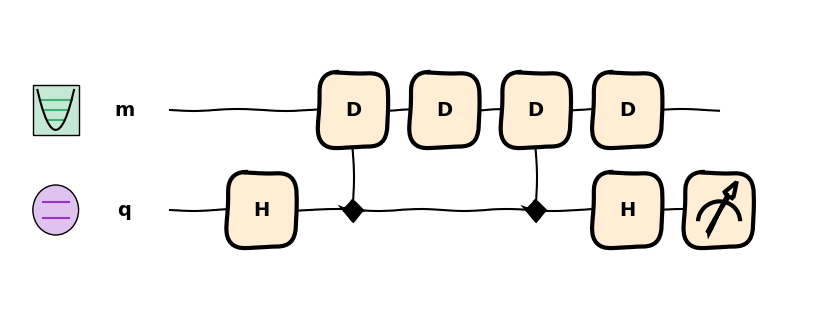

In [20]:
def circuit(beta):
    qml.H('q')
    hqml.CD(beta, 0, ['q', 'm'])
    hqml.D(beta, np.pi/2, 'm')
    hqml.CD(-beta, 0, ['q', 'm'])
    hqml.D(-beta, np.pi/2, 'm')
    qml.H('q')
    return hqml.expval(qml.Z('q'))

hqml.draw_mpl(circuit, style="sketch")(0.5)
plt.show()

Let's simulate it on Bosonic Qiskit analytically.

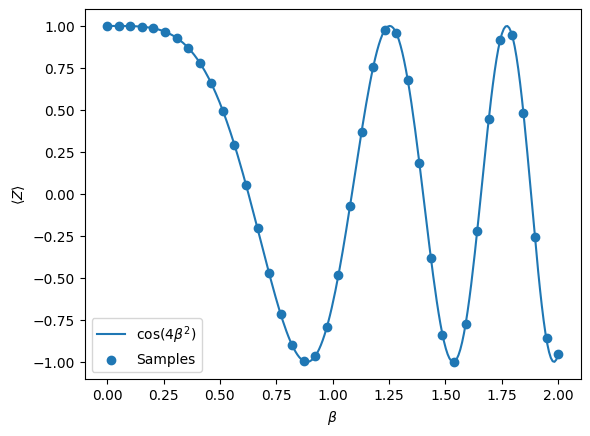

In [22]:
bq_dev = qml.device('bosonicqiskit.hybrid', max_fock_level=16)
sim = qml.QNode(circuit, bq_dev)
sim = qml.batch_params(sim)

beta_sample = qml.numpy.linspace(0, 2, 40)
expval = sim(beta_sample)

beta_exact = np.linspace(0, 2, 250)
plt.plot(beta_exact, np.cos(4 * beta_exact**2), label=r'$\cos(4\beta^2)$')

plt.scatter(beta_sample, expval, label="Samples")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\langle Z\rangle$")
plt.legend()
plt.show()

Our simulated circuits match the theoretical expectation, so now we're confident the circuit definition is correct. We'd like to export it to run on the hardware. This can be done by wrapping the circuit in the Sandia ion trap device instead.

In [23]:
qscout_dev = qml.device('sandiaqscout.hybrid', n_qubits=2)
hw = qml.QNode(circuit, qscout_dev)
hw = qml.set_shots(hw, 1024)

Just like before, we can visualize the circuit and see what layout the device chose. The device chose the mapping

```
q -> 1
m -> m1i1
(dynamically allocated) anc -> 0
```

The dynamic ancilla qubit is used to realize the $D$ gate on the qumode by applying $CD$ to the ancilla in state $\ket{0}$.

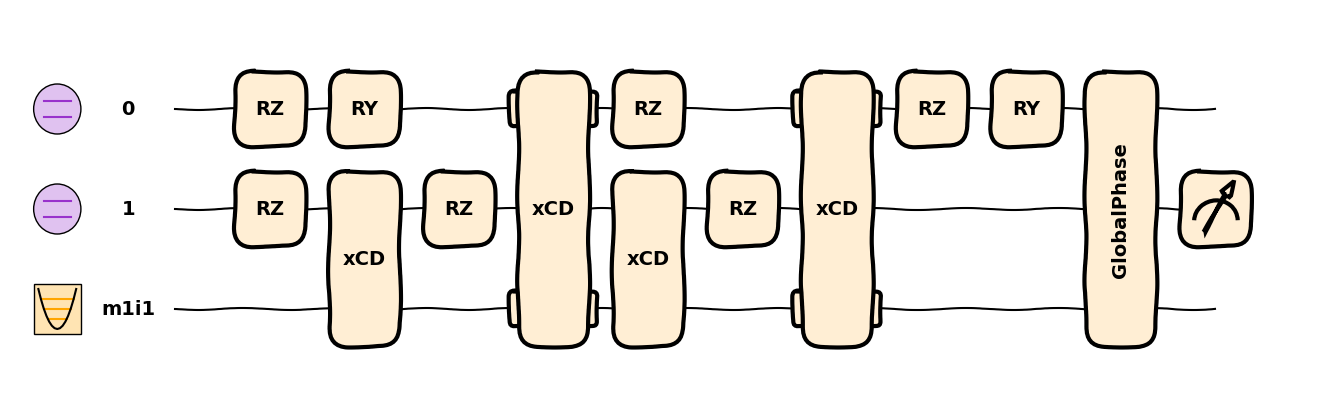

In [24]:
hqml.draw_mpl(hw, level="device", style="sketch", **draw_options)(0.5)
plt.show()

Now let's export our circuit to Jaqal so it can be run on-device. We'll use 3 values of $\beta$ to show how one can encode parameter sweeps.

In [25]:
from hybridlane.devices.sandia_qscout import to_jaqal

hw = qml.batch_params(hw)
betas = qml.numpy.array([1.0, 2, 3])
ir = to_jaqal(hw, level="device", precision=5)(betas)
print(ir)

from Calibration_PulseDefinitions.QubitBosonPulses usepulses *

register q[2]

subcircuit {
	Rz q[1] 6.2832
	xCD q[1] 1 1 1.0 0.0
	Rz q[1] 6.2832
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	xCD q[0] 1 1 0.0 1.0
	Rz q[0] 6.2832
	xCD q[1] 1 1 -1.0 -0.0
	Rz q[1] 6.2832
	xCD q[0] 1 1 -0.0 -1.0
	Rz q[0] 3.1416
	Ry q[0] 1.5708
}
subcircuit {
	Rz q[1] 6.2832
	xCD q[1] 1 1 2.0 0.0
	Rz q[1] 6.2832
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	xCD q[0] 1 1 0.0 2.0
	Rz q[0] 6.2832
	xCD q[1] 1 1 -2.0 -0.0
	Rz q[1] 6.2832
	xCD q[0] 1 1 -0.0 -2.0
	Rz q[0] 3.1416
	Ry q[0] 1.5708
}
subcircuit {
	Rz q[1] 6.2832
	xCD q[1] 1 1 3.0 0.0
	Rz q[1] 6.2832
	Rz q[0] 3.1416
	Ry q[0] 1.5708
	xCD q[0] 1 1 0.0 3.0
	Rz q[0] 6.2832
	xCD q[1] 1 1 -3.0 -0.0
	Rz q[1] 6.2832
	xCD q[0] 1 1 -0.0 -3.0
	Rz q[0] 3.1416
	Ry q[0] 1.5708
}


Thus we've shown the full pipeline from defining a circuit, validating it with Bosonic Qiskit, then transpiling it to the ion trap and exporting it to Jaqal. While we can't run on the hardware from here, if you _could_, you might get something like this:

![QSCOUT displacement benchmark](cd_displacement_qscout.svg)